# RL Group Project: Starter Notebook

## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the
  state and action spaces are small enough to apply classical RL methods
  directly.

- In **Configuration B**, you will move to a continuous-observation ICU
  environment that is clinically grounded and significantly more challenging.

Three realistic failure modes are present in Configuration B, each reflecting a
real scenario encountered in clinical AI deployments. The first is episodic
observation noise, where monitoring equipment occasionally malfunctions. The
second is episodic missing observations, representing situations where lab
results are simply unavailable for an entire episode. The third is acute
clinical events, which are sudden and irreversible patient deteriorations that
occur independently of any treatment given.

---

### Group Members

Fill in before submitting:

Name of the Group: Group X

```
Student 1: Diogo Carvalho - 20221935
Student 2: Ricardo Pereira - 20250343
Student 3: Yehor Malakhov - 20221691
```


## 0. Setup & Imports


In [4]:
import os
import sys
import warnings
from typing import TYPE_CHECKING

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from stable_baselines3 import DQN

from config_a import (
    evaluate_deterministic_policy,
    greedy_policy_from_q,
    policy_iteration,
    train_q_learning,
    train_sarsa,
    tune_q_learning,
    tune_sarsa,
)
from config_b import tune_dqn

#  Import constants and env factory from env_setup.py
from envs.env_setup import (
    ENV_ID,
    GAMMA,
    INTENSITY,
    LAM,
    N_ACTIONS,
    N_STATES,
    SOFA_BIAS,
    STATE_DIED,
    STATE_SURVIVED,
    make_sepsis_env,
)

if TYPE_CHECKING:
    import icu_sepsis

In [5]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

os.makedirs("plots", exist_ok=True)
PLOTS_DIR = "plots"

SEED = 42
np.random.seed(SEED)


print(f"ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}")
print(
    f"Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)"
)
print("Setup complete!")

ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [3]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f"Required config: sofa_bias={SOFA_BIAS}, lam={LAM}")

Required config: sofa_bias=5.0, lam=0.02


---

## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working
with. The insights you gain here should inform your report's Methodology
section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data.
Each episode represents the trajectory of one ICU patient. The agent observes a
discrete integer state (ranging from 0 to 715) and must select one of 25
treatment actions corresponding to combinations of vasopressor and IV fluid dose
levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all
intermediate steps**, with a discount factor γ = 1.


In [6]:
#  Instantiate and inspect the raw environment
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f"Observation space : {env.observation_space} discrete integer state")
print(f"Action space      : {env.action_space}")
print(f"Initial state     : {obs}")
print()

#  Extract the full MDP model

# pyright reports wrong type for env.unwrapped
raw: icu_sepsis.ICUSepsisEnv = env.unwrapped  # pyright: ignore[reportAssignmentType]
P: np.ndarray[tuple[int, int, int], np.dtype[np.float64]] = (
    raw._tx_mat
)  # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp: np.ndarray[tuple[int, int, int], np.dtype[np.float64]] = (
    raw._r_mat
)  # (716, 25, 716) — R[s, a, s']
R: np.ndarray[tuple[int, int], np.dtype[np.float64]] = (P * R_sasp).sum(
    axis=2
)  # (716, 25)      — E[r | s, a]

print(f"Transition matrix P : {P.shape}  (S × A × S')")
print(f"Reward matrix R     : {R.shape}  (S × A)")
print(f"Reward range        : [{R.min():.3f}, {R.max():.3f}]")
print()

Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [5]:
#  Random baseline: establish the performance floor
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r
            steps += 1
            done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f"Random agent ({len(rand_returns)} episodes):")
print(f"  Mean return    : {np.mean(rand_returns):.4f}")
print(f"  Survival rate  : {survival_rate:.1f}%")
print(f"  Mean ep length : {np.mean(rand_lengths):.1f} steps")
print()
print("All Config A algorithms must beat the random baseline.")

Random agent (1000 episodes):
  Mean return    : 0.5816
  Survival rate  : 68.1%
  Mean ep length : 10.0 steps

All Config A algorithms must beat the random baseline.


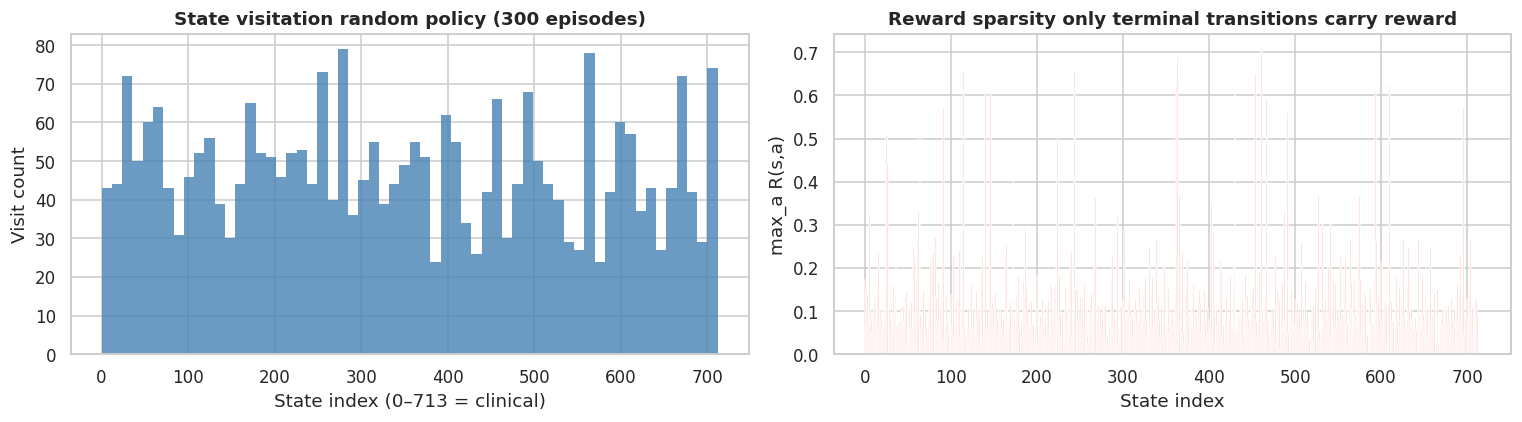

In [6]:
#  Visualise state visitation and reward structure
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("State index (0–713 = clinical)")
axes[0].set_ylabel("Visit count")
axes[0].set_title(
    "State visitation random policy (300 episodes)", fontweight="bold"
)

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(
    range(N_STATES), R.max(axis=1), color="tomato", width=1.0, alpha=0.8
)
axes[1].set_xlabel("State index")
axes[1].set_ylabel("max_a R(s,a)")
axes[1].set_title(
    "Reward sparsity only terminal transitions carry reward", fontweight="bold"
)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/configA_env_exploration.png", bbox_inches="tight")
plt.show()

---

# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`,
totalling 17,900 entries. This size is entirely manageable in memory, which is
precisely what motivates the use of tabular algorithms here.


### Policy Iteration


Policy Iteration:   0%|          | 3/1000 [00:00<02:18,  7.21it/s]


Converged after 4 iterations.


Policy Iteration evaluation: 100%|██████████| 50000/50000 [00:07<00:00, 6785.37it/s]


Policy Iteration
  Expected return from initial distribution : -0.0397
  Empirical mean return                   : 0.7859
  Survival rate                           : 82.4%
  Mean episode length                     : 9.8 steps



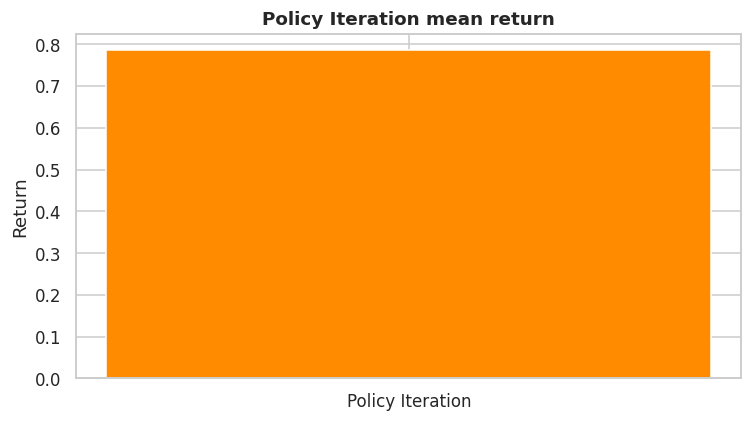

In [7]:
TERMINAL_STATES = [STATE_SURVIVED, STATE_DIED]

pi_policy, pi_values = policy_iteration(
    P,
    R,
    # terminal_states=TERMINAL_STATES,
    gamma=GAMMA,
    max_policy_iter=1_000,
)
pi_expected_return = float(np.dot(raw._d_0, pi_values))
pi_returns, pi_lengths = evaluate_deterministic_policy(
    make_sepsis_env(),
    pi_policy,
    n_episodes=50_000,
    seed=SEED,
    progress_desc="Policy Iteration evaluation",
)

print("Policy Iteration")
print(f"  Expected return from initial distribution : {pi_expected_return:.4f}")
print(f"  Empirical mean return                   : {pi_returns.mean():.4f}")
print(
    f"  Survival rate                           : {(pi_returns > 0).mean() * 100:.1f}%"
)
print(
    f"  Mean episode length                     : {pi_lengths.mean():.1f} steps"
)
# print(f"  Evaluation sweeps used                  : {pi_eval_iterations}")
print()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Policy Iteration"], [pi_returns.mean()], color=["darkorange"])
ax.set_title("Policy Iteration mean return", fontweight="bold")
ax.set_ylabel("Return")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/configA_policy_iteration.png", bbox_inches="tight")
plt.show()

### Q-Learning


In [ ]:
q_study = tune_q_learning(
    make_sepsis_env,
    n_states=N_STATES,
    n_actions=N_ACTIONS,
    gamma=GAMMA,
    n_trials=50,
    train_episodes=100_000,
    validation_episodes=50_000,
    seed=SEED,
)
print("Optuna results for Q-learning")
print(f"  Best params : {q_study.best_params}")
print(f"  Best score   : {q_study.best_value:.6f}")
print()

q_env = make_sepsis_env()
q_table, q_returns = train_q_learning(
    q_env,
    n_states=N_STATES,
    n_actions=N_ACTIONS,
    gamma=GAMMA,
    episodes=100_000,
    alpha=q_study.best_params["alpha"],
    epsilon_start=1.0,
    epsilon_end=q_study.best_params["epsilon_end"],
    epsilon_decay=q_study.best_params["epsilon_decay"],
    seed=SEED,
)
q_env.close()

q_policy = greedy_policy_from_q(q_table)
q_returns_eval, q_lengths_eval = evaluate_deterministic_policy(
    make_sepsis_env(), q_policy, n_episodes=50_000, seed=SEED
)
q_ma = pl.Series(q_returns).rolling_mean(window_size=100)

print("Q-learning")
print(f"  Training return last 250 episodes       : {q_ma[-1]:.4f}")
print(
    f"  Empirical mean return                   : {q_returns_eval.mean():.4f}"
)
print(
    f"  Survival rate                           : {(q_returns_eval > 0).mean() * 100:.1f}%"
)
print(
    f"  Mean episode length                     : {q_lengths_eval.mean():.1f} steps"
)
print()

fig, axes = plt.subplots(1, 1, figsize=(14, 4))
axes.plot(q_ma, color="steelblue", linewidth=2)
axes.set_title(
    "Q-learning training curve (100-episode moving average)", fontweight="bold"
)
axes.set_xlabel("Episode")
axes.set_ylabel("Return")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/configA_q_learning.png", bbox_inches="tight")
plt.show()

### SARSA


In [ ]:
sarsa_study = tune_sarsa(
    make_sepsis_env,
    n_states=N_STATES,
    n_actions=N_ACTIONS,
    gamma=GAMMA,
    n_trials=50,
    train_episodes=100_000,
    validation_episodes=50_000,
    seed=SEED,
)
print("Optuna results for SARSA")
print(f"  Best params : {sarsa_study.best_params}")
print(f"  Best score   : {sarsa_study.best_value:.6f}")
print()

sarsa_env = make_sepsis_env()
sarsa_q_table, sarsa_returns = train_sarsa(
    sarsa_env,
    n_states=N_STATES,
    n_actions=N_ACTIONS,
    gamma=GAMMA,
    episodes=100_000,
    alpha=sarsa_study.best_params["alpha"],
    epsilon_start=1.0,
    epsilon_end=sarsa_study.best_params["epsilon_end"],
    epsilon_decay=sarsa_study.best_params["epsilon_decay"],
    seed=SEED,
)
sarsa_env.close()

sarsa_policy = greedy_policy_from_q(sarsa_q_table)
sarsa_returns_eval, sarsa_lengths_eval = evaluate_deterministic_policy(
    make_sepsis_env(), sarsa_policy, n_episodes=50_000, seed=SEED
)
sarsa_ma = pl.Series(sarsa_returns).rolling_mean(window_size=250)

print("SARSA")
print(f"  Training return last 250 episodes       : {sarsa_ma[-1]:.4f}")
print(
    f"  Empirical mean return                   : {sarsa_returns_eval.mean():.4f}"
)
print(
    f"  Survival rate                           : {(sarsa_returns_eval > 0).mean() * 100:.1f}%"
)
print(
    f"  Mean episode length                     : {sarsa_lengths_eval.mean():.1f} steps"
)
print()

if "rand_returns" in globals():
    random_returns = np.asarray(rand_returns)
elif "run_random_baseline" in globals():
    random_returns, _ = run_random_baseline(n_episodes=200)
else:
    random_returns = None

if random_returns is not None:
    random_mean = float(np.mean(random_returns))
    print("Comparison to random baseline")
    print(f"  Random mean return                      : {random_mean:.4f}")
    print(
        f"  SARSA improvement                       : {sarsa_returns_eval.mean() - random_mean:.4f}"
    )
else:
    random_mean = np.nan
    print(
        "Random baseline was not available in the current kernel; run the earlier baseline cell to populate that comparison."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(sarsa_ma, color="seagreen", linewidth=2)
axes[0].set_title(
    "SARSA training curve (250-episode moving average)", fontweight="bold"
)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Return")

axes[1].bar(
    ["Random", "SARSA"],
    [random_mean, sarsa_returns_eval.mean()],
    color=["gray", "seagreen"],
)
axes[1].set_title("SARSA mean return", fontweight="bold")
axes[1].set_ylabel("Return")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/configA_sarsa.png", bbox_inches="tight")
plt.show()

In [ ]:
policy_iteration_mean = float(pi_returns.mean())
q_learning_mean = float(q_returns_eval.mean())
sarsa_mean = float(sarsa_returns_eval.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(q_ma, color="steelblue", linewidth=1.8, label="Q-learning")
axes[0].plot(sarsa_ma, color="seagreen", linewidth=1.8, label="SARSA")
axes[0].axhline(
    policy_iteration_mean,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="Policy Iteration",
)
axes[0].set_title(
    "Training curves and Policy Iteration reference", fontweight="bold"
)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Return")
axes[0].legend(frameon=False)

axes[1].bar(
    ["Policy Iteration", "Q-learning", "SARSA"],
    [policy_iteration_mean, q_learning_mean, sarsa_mean],
    color=["darkorange", "steelblue", "seagreen"],
)
axes[1].set_title("Mean return comparison", fontweight="bold")
axes[1].set_ylabel("Return")

plt.tight_layout()
plt.savefig(
    f"{PLOTS_DIR}/configA_algorithm_comparison.png", bbox_inches="tight"
)
plt.show()

---

# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by
discretising a set of clinical measurements into a small number of categories.
**Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III
data, but with two fundamental changes that make the problem substantially
harder.

**Change 1 — Continuous observations.** The agent now receives a
**47-dimensional continuous feature vector** instead of a single discrete index.
This vector contains the actual normalised physiological measurements used in
the original Komorowski et al. (2018) AI Clinician study, including SOFA score,
heart rate, lactate, blood pressure, creatinine, and 42 other clinical
variables.

With continuous observations, a tabular Q-table is no longer feasible: it would
require one entry per unique float vector, making it effectively infinite.

**Change 2 — Clinical reality wrappers.** Config B injects three orthogonal
failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction.
When active, the observations received by the agent are corrupted by noise for
the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results
are unavailable for a full episode. This tests how well the agent handles
partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient
deterioration events such as cardiac arrest or acute organ failure. These occur
independently of any treatment decision and represent irreducible stochasticity
in the environment.

Key environment properties for Config B:

- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity
  penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector,
  potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [4]:
#  Import Clinical Reality Wrappers from wrappers.py

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print("Clinical reality wrappers imported from wrappers.py:")
print("  EpisodicNoisyObsEnv   : episodic monitor malfunction")
print("  EpisodicMissingObsEnv : episodic missing lab values")
print("  AcuteEventEnv         : rare sudden patient death")
print()
print("Required Config B env: make_clinical_env() with default parameters")

Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [5]:
#  Verify wrappers and random baseline on clinical environment
try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print("Clinical environment loaded successfully!")
    print(f"Observation space : {env_clinical.observation_space}")
    print(f"Action space      : {env_clinical.action_space}")
    print(f"Info keys         : {list(info.keys())}")
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns = []
    clean_returns = []
    missing_returns = []
    nomiss_returns = []
    acute_episodes = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy = info.get("noisy_episode", False)
        ep_missing = info.get("missing_features") is not None
        ep_acute = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get("acute_event", False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:
            noisy_returns.append(total_r)
        else:
            clean_returns.append(total_r)
        if ep_missing:
            missing_returns.append(total_r)
        else:
            nomiss_returns.append(total_r)
        if ep_acute:
            acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print("=== Random Baseline: Clinical Environment (1000 episodes) ===")
    print(f"Overall mean return   : {np.mean(clinical_rand_returns):.4f}")
    print(
        f"Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0) * 100:.1f}%"
    )
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f"Error: {e}")
    print(
        "Make sure continuous_sepsis_env.py is in the project root and dependencies are installed."
    )
    clinical_rand_mean = 0.78

Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']


=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5749
Overall survival rate : 66.8%



In [6]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, "env"):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv
